<a href="https://colab.research.google.com/github/thisismemayanka/analysis-projects/blob/main/3_multilevel_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn statsmodels

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

In [ ]:
import pandas as pd

# Original link:
# https://drive.google.com/file/d/1sgKS5RAAR6Um_UklK2gU2LzXDmqRigO0/view?usp=sharing

# Step 1: Extract the file ID (the part after `/d/` and before `/view`)
file_id = "1sgKS5RAAR6Um_UklK2gU2LzXDmqRigO0"

# Step 2: Build a direct download link
download_url = f"https://drive.google.com/uc?id={file_id}"

# Step 3: Read into pandas
df = pd.read_csv(download_url)

print(df.shape)
print(df.head())


(101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No        

In [ ]:
df = df[
    [
        "medical_specialty",
        "age",
        "num_lab_procedures",
        "num_medications",
        "number_diagnoses",
        "time_in_hospital"
    ]
]

In [ ]:
df = df[
    (df["medical_specialty"] != "?")
]

df = df.dropna()

print(df.shape)

(51817, 6)


In [ ]:
age_map = {
    "[0-10)":5,
    "[10-20)":15,
    "[20-30)":25,
    "[30-40)":35,
    "[40-50)":45,
    "[50-60)":55,
    "[60-70)":65,
    "[70-80)":75,
    "[80-90)":85,
    "[90-100)":95
}

df["age_num"] = df["age"].map(age_map)

In [ ]:
counts = df["medical_specialty"].value_counts()

valid_specialties = counts[
    counts > 500
].index

df = df[
    df["medical_specialty"]
    .isin(valid_specialties)
]

In [ ]:
df["medical_specialty"].value_counts().head(20)

,count
medical_specialty,
InternalMedicine,14635
Emergency/Trauma,7565
Family/GeneralPractice,7440
Cardiology,5352
Surgery-General,3099
Nephrology,1613
Orthopedics,1400
Orthopedics-Reconstructive,1233
Radiologist,1140


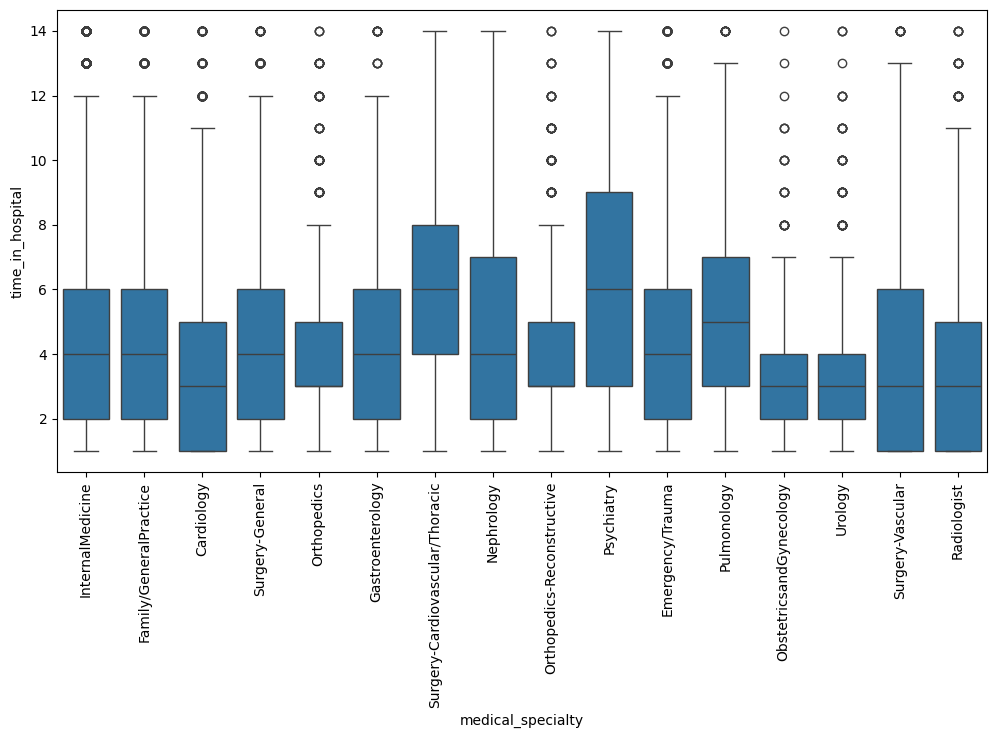

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="medical_specialty",
    y="time_in_hospital"
)

plt.xticks(rotation=90)

plt.show()

In [ ]:
null_model = smf.mixedlm(
    "time_in_hospital ~ 1",
    data=df,
    groups=df["medical_specialty"]
)

null_result = null_model.fit()

print(null_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: time_in_hospital
No. Observations: 48307   Method:             REML            
No. Groups:       16      Scale:              8.5697          
Min. group size:  533     Log-Likelihood:     -120471.6161    
Max. group size:  14635   Converged:          Yes             
Mean group size:  3019.2                                      
----------------------------------------------------------------
             Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
----------------------------------------------------------------
Intercept    4.397      0.212   20.710   0.000    3.981    4.813
Group Var    0.714      0.084                                   



In [ ]:
specialty_var = (
    null_result.cov_re.iloc[0,0]
)

patient_var = (
    null_result.scale
)

icc = specialty_var / (
    specialty_var + patient_var
)

print(
    f"ICC = {icc:.3f}"
)

ICC = 0.077


In [ ]:
mixed_model = smf.mixedlm(
    """
    time_in_hospital
    ~ age_num
    + num_lab_procedures
    + num_medications
    + number_diagnoses
    """,
    data=df,
    groups=df["medical_specialty"]
)

mixed_result = mixed_model.fit()

print(mixed_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: time_in_hospital
No. Observations: 48307   Method:             REML            
No. Groups:       16      Scale:              6.0997          
Min. group size:  533     Log-Likelihood:     -112284.5916    
Max. group size:  14635   Converged:          Yes             
Mean group size:  3019.2                                      
--------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept          -1.313    0.249  -5.281 0.000 -1.800 -0.825
age_num             0.019    0.001  25.443 0.000  0.018  0.021
num_lab_procedures  0.023    0.001  36.096 0.000  0.022  0.024
num_medications     0.160    0.002 102.200 0.000  0.157  0.163
number_diagnoses    0.119    0.006  18.909 0.000  0.106  0.131
Group Var           0.924    0.118                            



In [ ]:
ols = smf.ols(
    """
    time_in_hospital
    ~ age_num
    + num_lab_procedures
    + num_medications
    + number_diagnoses
    """,
    data=df
).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:       time_in_hospital   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     4376.
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:05:57   Log-Likelihood:            -1.1375e+05
No. Observations:               48307   AIC:                         2.275e+05
Df Residuals:                   48302   BIC:                         2.276e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.1446      0

In [ ]:
effects = mixed_result.random_effects

effects_df = pd.DataFrame({
    "specialty": effects.keys(),
    "effect":[v[0] for v in effects.values()]
})

effects_df = effects_df.sort_values(
    "effect"
)

/tmp/ipykernel_5162/1142472482.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "effect":[v[0] for v in effects.values()]


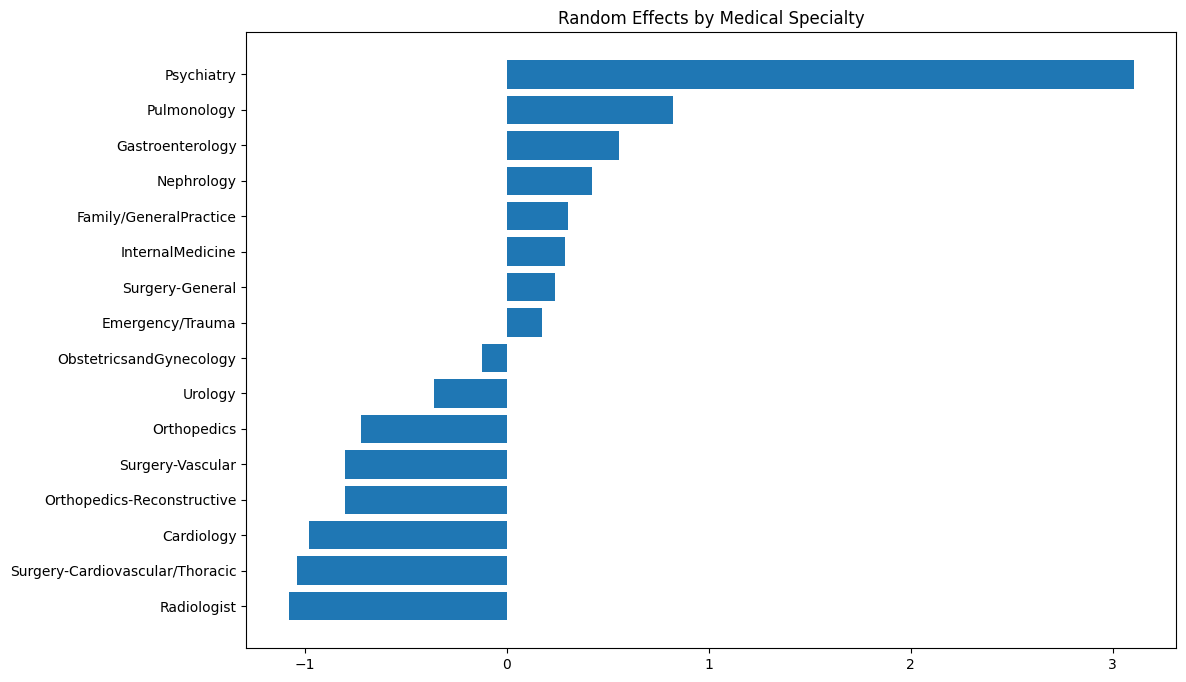

In [ ]:
plt.figure(figsize=(12,8))

plt.barh(
    effects_df["specialty"],
    effects_df["effect"]
)

plt.title(
    "Random Effects by Medical Specialty"
)

plt.show()

In [ ]:
variance_df = pd.DataFrame({
    "Source":[
        "Specialty",
        "Patient"
    ],
    "Variance":[
        specialty_var,
        patient_var
    ]
})

variance_df

,Source,Variance
0,Specialty,0.713661
1,Patient,8.569712


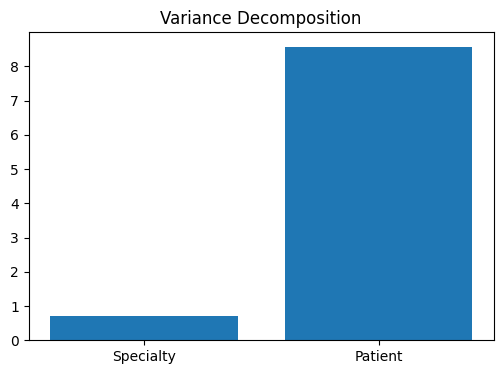

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    variance_df["Source"],
    variance_df["Variance"]
)

plt.title(
    "Variance Decomposition"
)

plt.show()